In [13]:
# Cell 1: Imports + Paths
import os, sys, glob, time, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage
import cv2

# ── Project root (works whether notebook is run from notebooks/ or from root) ──
_nb_dir      = os.path.abspath(".")
_proj_root   = _nb_dir if os.path.basename(_nb_dir) != "notebooks" else os.path.dirname(_nb_dir)
sys.path.insert(0, _proj_root)          # so  'from src.xxx import …'  works

# ── CASIA dataset root ─────────────────────────────────────────────────────────
_dataset_candidates = [
    os.path.join(_proj_root, "CASIA-Iris-Thousand", "CASIA-Iris-Thousand"),
    os.path.join(_proj_root, "CASIA-Iris-Thousand"),
    r"C:\Users\Mridul\OneDrive\Desktop\Iris_Recognition_Project\CASIA-Iris-Thousand\CASIA-Iris-Thousand",
    r"C:\Users\Mridul\OneDrive\Desktop\Iris_Recognition_Project\CASIA-Iris-Thousand",
    "/kaggle/input/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand",
]
DATASET_ROOT = next((p for p in _dataset_candidates if os.path.isdir(p) and os.listdir(p)), None)
if DATASET_ROOT is None:
    raise RuntimeError("CASIA dataset not found. Check DATASET_ROOT candidates.")

# ── Output directories ─────────────────────────────────────────────────────────
OUTPUTS_ROOT     = os.path.join(_proj_root, "outputs")
PREPROC_ROOT     = os.path.join(OUTPUTS_ROOT, "preprocessed_iris")   # subject sub-dirs live here
METADATA_CSV     = os.path.join(OUTPUTS_ROOT, "preprocessed_iris_metadata.csv")

os.makedirs(PREPROC_ROOT, exist_ok=True)

print(f"Project root      : {_proj_root}")
print(f"Dataset root      : {DATASET_ROOT}")
print(f"Preprocessed root : {PREPROC_ROOT}")
print(f"Metadata CSV path : {METADATA_CSV}")


Project root      : c:\Users\Mridul\OneDrive\Desktop\Iris_Recognition_Project
Dataset root      : c:\Users\Mridul\OneDrive\Desktop\Iris_Recognition_Project\CASIA-Iris-Thousand\CASIA-Iris-Thousand
Preprocessed root : c:\Users\Mridul\OneDrive\Desktop\Iris_Recognition_Project\outputs\preprocessed_iris
Metadata CSV path : c:\Users\Mridul\OneDrive\Desktop\Iris_Recognition_Project\outputs\preprocessed_iris_metadata.csv


In [14]:
# Cell 2: Dataset Metadata

_FNAME_RE = re.compile(r"S5(\d{3})([LR])(\d{2})\.jpg", re.IGNORECASE)

def load_dataset_records(dataset_root: str) -> pd.DataFrame:
    all_jpg = glob.glob(os.path.join(dataset_root, "**", "*.jpg"), recursive=True)
    records = []
    for path in all_jpg:
        fname = os.path.basename(path)
        m = _FNAME_RE.match(fname)
        if m:
            sub_id, eye, img_num = m.group(1), m.group(2).upper(), int(m.group(3))
        else:
            # Fallback: infer from directory structure  …/<subject>/<L|R>/…
            parts = os.path.normpath(path).split(os.sep)
            sub_id = parts[-3] if len(parts) >= 3 else "000"
            eye    = parts[-2].upper() if len(parts) >= 2 else "L"
            img_num = -1
        records.append({
            "subject_id"    : sub_id,
            "eye"           : eye,
            "identity"      : f"{sub_id}_{eye}",
            "image_index"   : img_num,
            "filename"      : fname,
            "original_path" : os.path.abspath(path),
        })
    df = pd.DataFrame(records)
    if not df.empty:
        df = df.sort_values(["subject_id", "eye", "image_index"]).reset_index(drop=True)
    return df

df_meta = load_dataset_records(DATASET_ROOT)

print("=== Dataset Metadata Summary ===")
print(f"Total images      : {len(df_meta):,}")
print(f"Unique subjects   : {df_meta['subject_id'].nunique()}")
print(f"Eye identities    : {df_meta['identity'].nunique()}")
print(f"Images/identity   : {len(df_meta)/df_meta['identity'].nunique():.1f}")
df_meta.head(8)


=== Dataset Metadata Summary ===
Total images      : 20,000
Unique subjects   : 1000
Eye identities    : 2000
Images/identity   : 10.0


,subject_id,eye,identity,image_index,filename,original_path
0,000,L,000_L,0,S5000L00.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
1,000,L,000_L,1,S5000L01.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
2,000,L,000_L,2,S5000L02.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
3,000,L,000_L,3,S5000L03.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
4,000,L,000_L,4,S5000L04.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
5,000,L,000_L,5,S5000L05.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
6,000,L,000_L,6,S5000L06.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
7,000,L,000_L,7,S5000L07.jpg,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...


In [15]:
# Cell 3: Preprocessing Functions
# ─────────────────────────────────────────────────────────────────────────────
# Steps: Specular inpainting → Pupil localisation → Limbus localisation
#        → Daugman Rubber-Sheet unwrap → CLAHE enhancement
# ─────────────────────────────────────────────────────────────────────────────

def remove_specular_highlights(img, thresh=240, radius=3):
    """Inpaint bright LED specular reflections."""
    mask = (img >= thresh).astype(np.uint8)
    if not np.any(mask):
        return img.copy()
    struct  = ndimage.generate_binary_structure(2, 2)
    dilated = ndimage.binary_dilation(mask, structure=struct, iterations=radius)
    median  = ndimage.median_filter(img, size=2 * radius + 1)
    out = img.copy();  out[dilated] = median[dilated]
    return out


def localize_pupil(img):
    """Return (cx, cy, r) of the pupil inner boundary."""
    sm = ndimage.median_filter(img, size=7)
    t  = min(max(int(np.percentile(sm, 10) * 1.3), 30), 80)
    binary = (sm < t).astype(np.uint8)
    struct = ndimage.generate_binary_structure(2, 2)
    closed = ndimage.binary_closing(binary, structure=struct, iterations=4)
    labeled, n = ndimage.label(closed)
    h, w = img.shape;  cx0, cy0 = w // 2, h // 2
    best_score, best = -1e9, (cx0, cy0, 42)
    for i in range(1, n + 1):
        mask_i = labeled == i
        area   = np.sum(mask_i)
        r      = np.sqrt(area / np.pi)
        if 20 <= r <= 85:
            cy, cx = ndimage.center_of_mass(mask_i)
            dist   = np.hypot(cx - cx0, cy - cy0)
            score  = area - dist * 40
            if score > best_score:
                best_score = score
                best = (int(round(cx)), int(round(cy)), int(round(r)))
    return best


def localize_iris_limbus(img, xp, yp, rp):
    """Return (xi, yi, ri) of the outer iris limbus boundary."""
    h, w   = img.shape
    min_r  = int(rp * 1.8);  max_r = int(min(rp * 3.6, min(w, h) // 2 - 10))
    if min_r >= max_r:  min_r, max_r = int(rp * 1.5), int(rp * 3.0)
    sm     = ndimage.gaussian_filter(img.astype(np.float32), sigma=2.0)
    angles = np.linspace(0, 2 * np.pi, 120, endpoint=False)
    valid  = [a for a in angles if not (np.pi/4 < a < 3*np.pi/4 or 5*np.pi/4 < a < 7*np.pi/4)]
    r_cands = np.arange(min_r, max_r, 2)
    intens  = []
    for r in r_cands:
        vals = []
        for a in valid:
            px2 = int(round(xp + r * np.cos(a)));  py2 = int(round(yp + r * np.sin(a)))
            if 0 <= px2 < w and 0 <= py2 < h:
                vals.append(float(sm[py2, px2]))
        intens.append(np.mean(vals) if vals else 0.0)
    best_r = int(rp * 2.5)
    if len(intens) > 3:
        best_r = int(r_cands[np.argmax(np.diff(intens))])
    return xp, yp, best_r


def daugman_unwrap(img, pupil, iris, radial_res=64, angular_res=256):
    """Daugman Polar Rubber Sheet → rectangular strip [radial_res × angular_res]."""
    xp, yp, rp = pupil;  xi, yi, ri = iris
    r_c  = np.linspace(0.0, 1.0, radial_res).reshape(-1, 1)
    th_c = np.linspace(0.0, 2 * np.pi, angular_res, endpoint=False).reshape(1, -1)
    x_map = ((1 - r_c) * (xp + rp * np.cos(th_c)) + r_c * (xi + ri * np.cos(th_c))).astype(np.float32)
    y_map = ((1 - r_c) * (yp + rp * np.sin(th_c)) + r_c * (yi + ri * np.sin(th_c))).astype(np.float32)
    return cv2.remap(img.astype(np.float32), x_map, y_map,
                     cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=0)


def clahe_enhance(strip, clip_limit=2.5, tile=(8, 8)):
    """CLAHE contrast enhancement on a normalised iris strip."""
    u8 = np.clip(strip, 0, 255).astype(np.uint8)
    return cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile).apply(u8)


def preprocess_iris(image_path, radial_res=64, angular_res=256):
    """Full end-to-end pipeline for one iris image."""
    raw = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if raw is None:
        raise ValueError(f"Cannot read: {image_path}")
    inpainted = remove_specular_highlights(raw)
    pupil     = localize_pupil(inpainted)
    iris      = localize_iris_limbus(inpainted, *pupil)
    unwrapped = daugman_unwrap(inpainted, pupil, iris, radial_res, angular_res)
    enhanced  = clahe_enhance(unwrapped)
    return {"raw": raw, "inpainted": inpainted, "pupil": pupil,
            "iris": iris, "unwrapped": unwrapped, "enhanced": enhanced}

print("[OK] All preprocessing functions defined.")


[OK] All preprocessing functions defined.


In [16]:
# Cell 4: Test Preprocessing on 1 Image

sample_row  = df_meta.iloc[0]
sample_path = sample_row["original_path"]
print(f"Testing on: {sample_path}")

t0  = time.time()
res = preprocess_iris(sample_path)
ms  = (time.time() - t0) * 1000

print(f"Processing time  : {ms:.1f} ms")
print(f"Raw image shape  : {res['raw'].shape}")
print(f"Pupil  (cx,cy,r) : {res['pupil']}")
print(f"Limbus (cx,cy,r) : {res['iris']}")
print(f"Unwrapped shape  : {res['unwrapped'].shape}")
print(f"Enhanced shape   : {res['enhanced'].shape}  │  "
      f"range [{res['enhanced'].min()}, {res['enhanced'].max()}]")


Testing on: c:\Users\Mridul\OneDrive\Desktop\Iris_Recognition_Project\CASIA-Iris-Thousand\CASIA-Iris-Thousand\000\L\S5000L00.jpg
Processing time  : 491.4 ms
Raw image shape  : (480, 640)
Pupil  (cx,cy,r) : (264, 257, 37)
Limbus (cx,cy,r) : (264, 257, 88)
Unwrapped shape  : (64, 256)
Enhanced shape   : (64, 256)  │  range [26, 246]


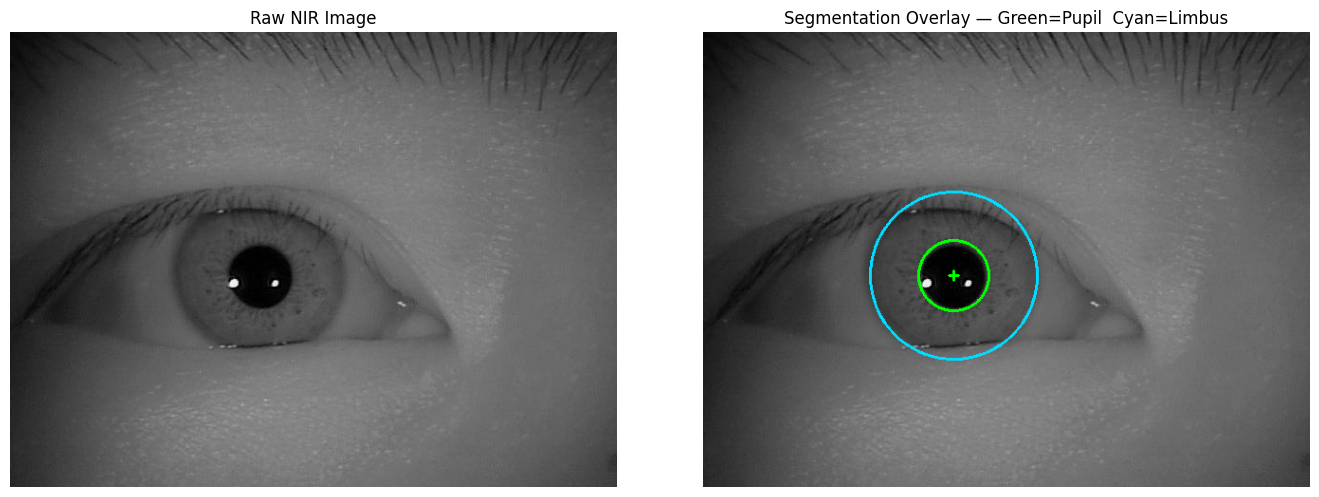

In [17]:
# Cell 5: Visualize Segmentation

def segmentation_overlay(img, pupil, iris):
    ov = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    px, py, pr = pupil
    cv2.circle(ov, (px, py), pr, (0, 255, 0), 2)                        # Green  = pupil
    cv2.drawMarker(ov, (px, py), (0, 255, 0), cv2.MARKER_CROSS, 10, 2)
    cv2.circle(ov, (iris[0], iris[1]), iris[2], (0, 220, 255), 2)       # Cyan   = limbus
    return ov

overlay = segmentation_overlay(res["raw"], res["pupil"], res["iris"])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(res["raw"], cmap="gray");  ax[0].set_title("Raw NIR Image");        ax[0].axis("off")
ax[1].imshow(overlay);                  ax[1].set_title("Segmentation Overlay — Green=Pupil  Cyan=Limbus");  ax[1].axis("off")
plt.tight_layout();  plt.show()


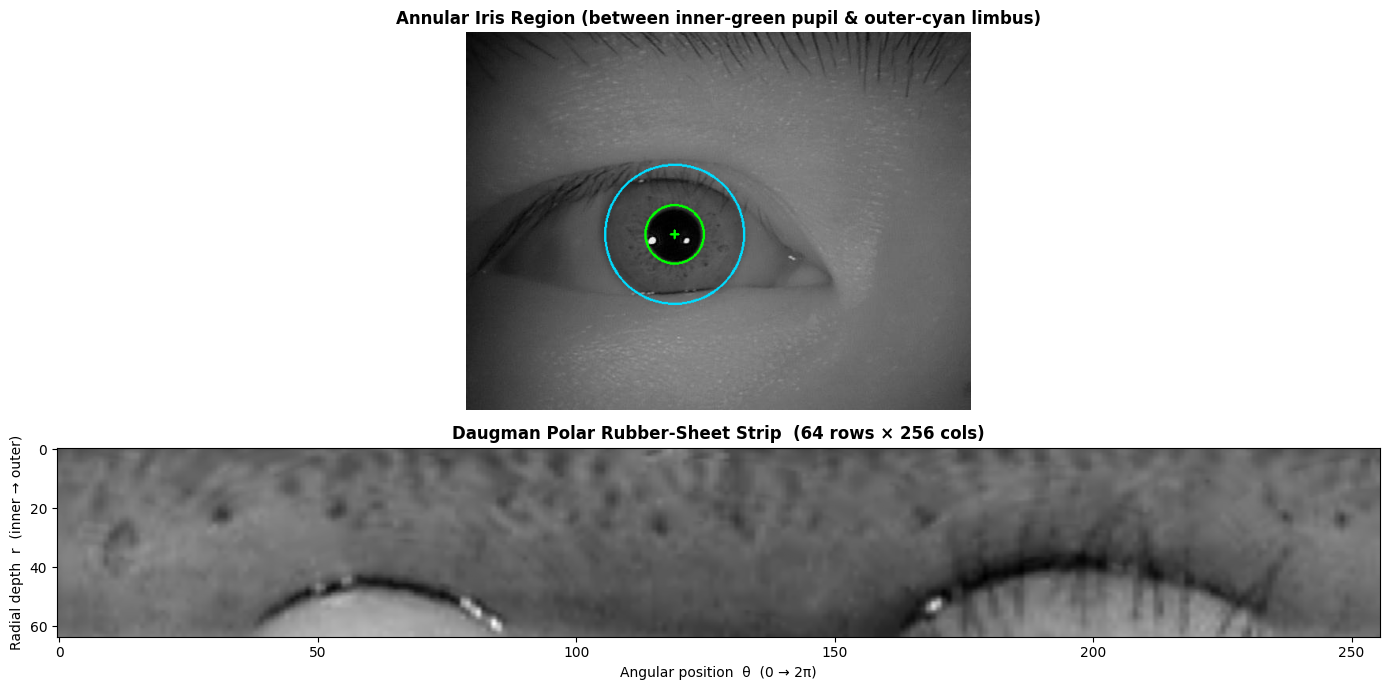

In [18]:
# Cell 6: Visualize Normalization (Daugman Rubber Sheet)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [2, 1]})
axes[0].imshow(overlay)
axes[0].set_title("Annular Iris Region (between inner-green pupil & outer-cyan limbus)", fontweight="bold")
axes[0].axis("off")
axes[1].imshow(res["unwrapped"], cmap="gray", aspect="auto")
axes[1].set_title(
    f"Daugman Polar Rubber-Sheet Strip  "
    f"({res['unwrapped'].shape[0]} rows × {res['unwrapped'].shape[1]} cols)",
    fontweight="bold")
axes[1].set_ylabel("Radial depth  r  (inner → outer)")
axes[1].set_xlabel("Angular position  θ  (0 → 2π)")
plt.tight_layout();  plt.show()


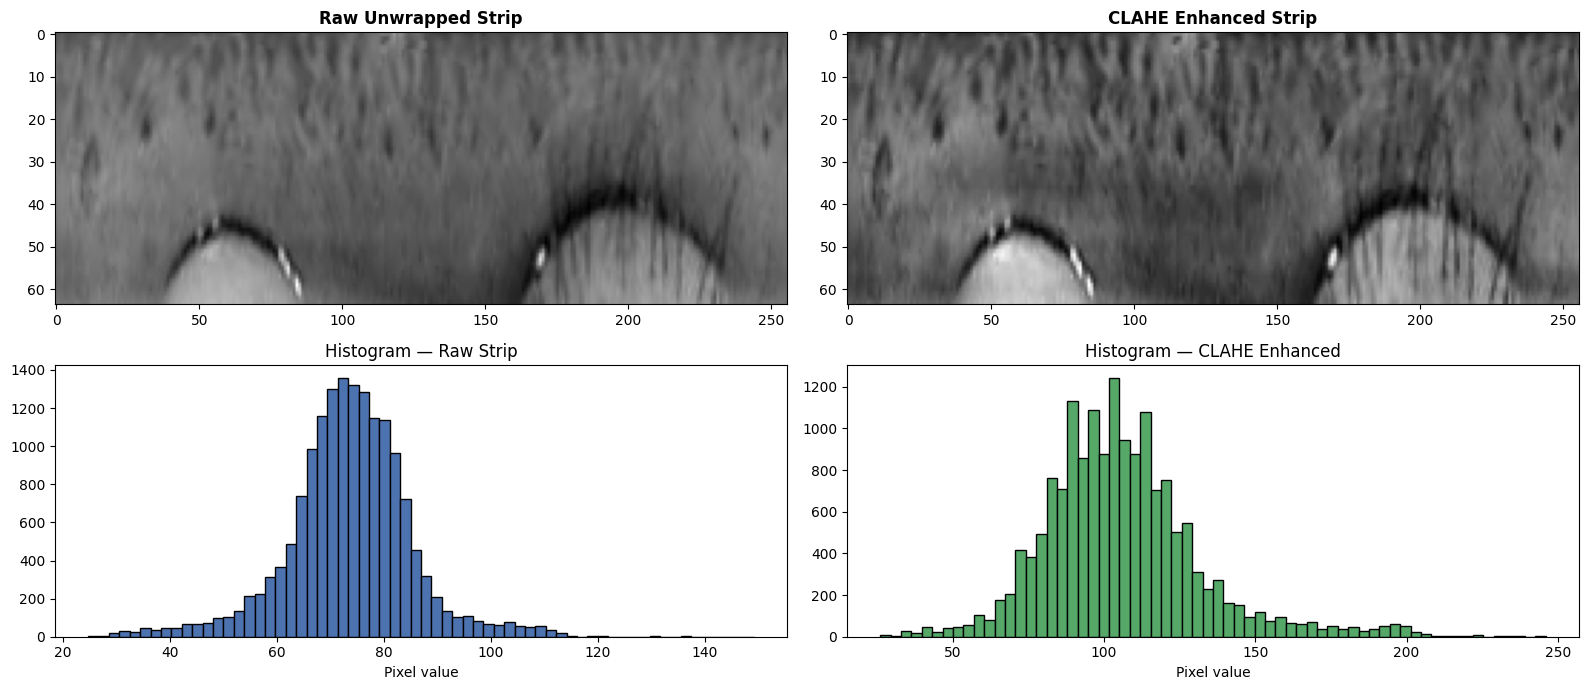

In [19]:
# Cell 7: Visualize Enhancement — Raw Unwrapped vs CLAHE Enhanced

fig, axes = plt.subplots(2, 2, figsize=(16, 7))

axes[0, 0].imshow(res["unwrapped"], cmap="gray", aspect="auto")
axes[0, 0].set_title("Raw Unwrapped Strip", fontweight="bold")

axes[0, 1].imshow(res["enhanced"], cmap="gray", aspect="auto")
axes[0, 1].set_title("CLAHE Enhanced Strip", fontweight="bold")

axes[1, 0].hist(res["unwrapped"].ravel(), bins=64, color="#4C72B0", edgecolor="black")
axes[1, 0].set_title("Histogram — Raw Strip");  axes[1, 0].set_xlabel("Pixel value")

axes[1, 1].hist(res["enhanced"].ravel(), bins=64, color="#55A868", edgecolor="black")
axes[1, 1].set_title("Histogram — CLAHE Enhanced");  axes[1, 1].set_xlabel("Pixel value")

plt.tight_layout();  plt.show()


In [20]:
# Cell 8: Test Preprocessing on Batch of 50 Images

batch50   = df_meta.iloc[:50]
results50 = []
timings   = []

for _, row in batch50.iterrows():
    t0  = time.time()
    r   = preprocess_iris(row["original_path"])
    timings.append((time.time() - t0) * 1000)
    results50.append({"identity": row["identity"],
                      "image_index": row["image_index"],
                      "pupil_r": r["pupil"][2],
                      "iris_r":  r["iris"][2],
                      "enhanced": r["enhanced"]})

print(f"50-image batch complete.")
print(f"Mean time / image : {np.mean(timings):.2f} ms")
print(f"Throughput        : {1000.0 / np.mean(timings):.1f} img/s")
print(f"Estimated time for 20,000 images : {np.mean(timings) * 20000 / 60000:.1f} minutes")


50-image batch complete.
Mean time / image : 413.77 ms
Throughput        : 2.4 img/s
Estimated time for 20,000 images : 137.9 minutes


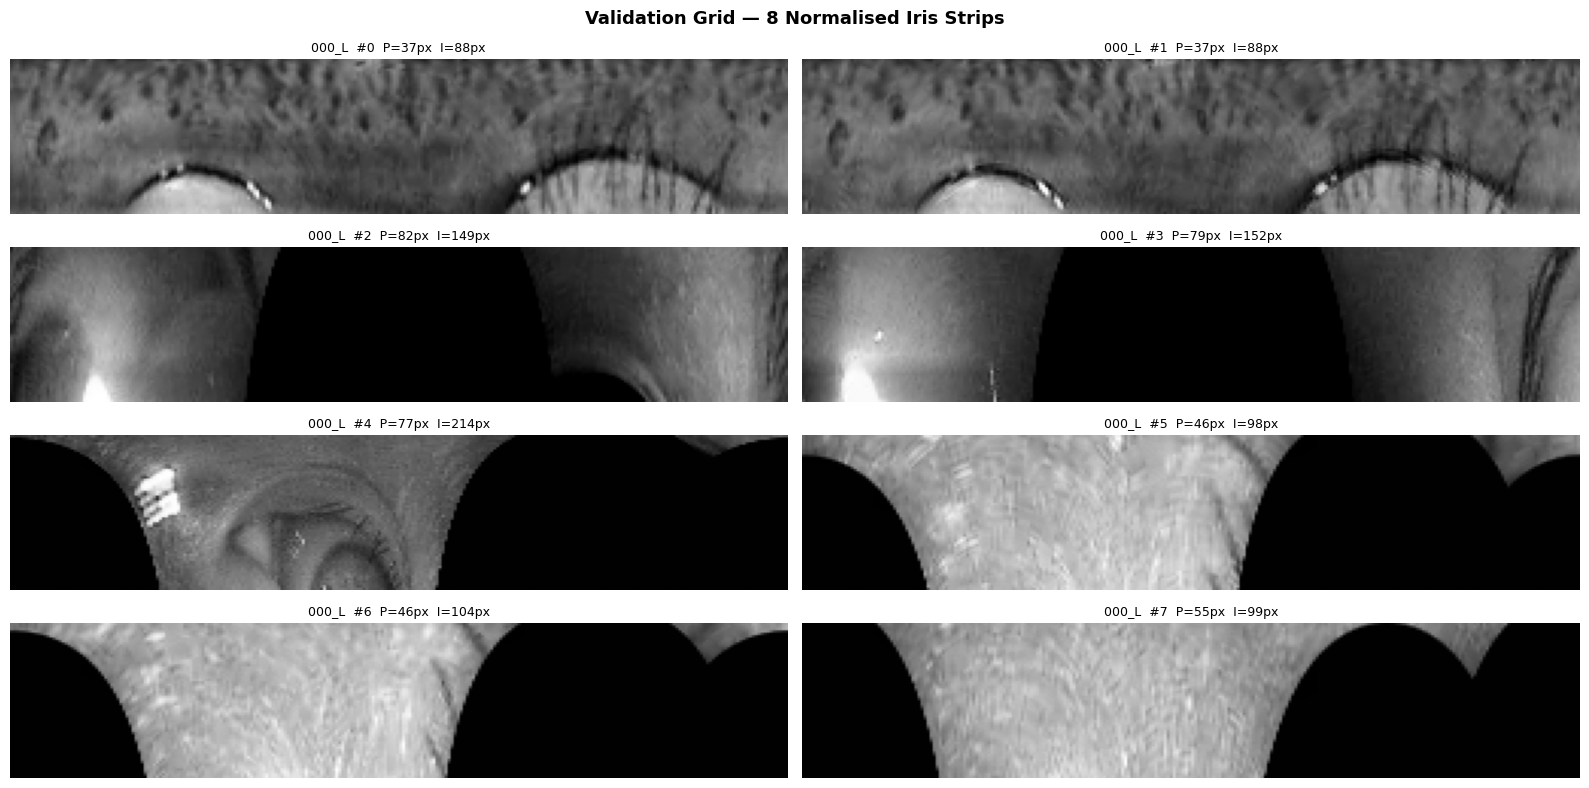

In [21]:
# Cell 9: Validate Processed Samples — Visual Grid of 8 Normalised Strips

fig, axes = plt.subplots(4, 2, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    s = results50[i]
    ax.imshow(s["enhanced"], cmap="gray", aspect="auto")
    ax.set_title(f"{s['identity']}  #{s['image_index']}  "
                 f"P={s['pupil_r']}px  I={s['iris_r']}px", fontsize=9)
    ax.axis("off")

plt.suptitle("Validation Grid — 8 Normalised Iris Strips", fontsize=13, fontweight="bold")
plt.tight_layout();  plt.show()


In [22]:
# Cell 10: Process ALL 20,000 Images — Sequential + Metadata CSV
#
# Output layout:
#   outputs/preprocessed_iris/<subject_id>/<image_name>_norm.png
#   outputs/preprocessed_iris_metadata.csv

meta_rows  = []    # accumulates one dict per processed image
failed     = []    # accumulates (original_path, error_string) for failed images

LOG_EVERY  = 500   # print progress every N images
t_total    = time.time()

for idx, row in df_meta.iterrows():
    sub_id  = row["subject_id"]
    eye     = row["eye"]
    img_idx = row["image_index"]
    orig    = row["original_path"]

    # ── per-subject sub-directory ──────────────────────────────────────────
    sub_dir = os.path.join(PREPROC_ROOT, sub_id)
    os.makedirs(sub_dir, exist_ok=True)

    # ── output filename preserves subject + eye + index ────────────────────
    image_name = f"S5{sub_id}{eye}{img_idx:02d}_norm.png"
    out_path   = os.path.join(sub_dir, image_name)

    # ── skip if already saved ──────────────────────────────────────────────
    if os.path.exists(out_path):
        meta_rows.append({
            "subject_id"    : sub_id,
            "eye"           : eye,
            "identity"      : row["identity"],
            "image_index"   : img_idx,
            "image_name"    : image_name,
            "original_path" : orig,
            "processed_path": out_path,
            "status"        : "skipped",
        })
        continue

    # ── preprocess one image ───────────────────────────────────────────────
    try:
        r          = preprocess_iris(orig)
        cv2.imwrite(out_path, r["enhanced"])
        status     = "ok"
    except Exception as exc:
        failed.append((orig, str(exc)))
        status = "failed"
        out_path = ""

    meta_rows.append({
        "subject_id"    : sub_id,
        "eye"           : eye,
        "identity"      : row["identity"],
        "image_index"   : img_idx,
        "image_name"    : image_name,
        "original_path" : orig,
        "processed_path": out_path,
        "status"        : status,
    })

    # ── progress log ──────────────────────────────────────────────────────
    n_done = idx + 1
    if n_done % LOG_EVERY == 0 or n_done == len(df_meta):
        elapsed = time.time() - t_total
        rate    = n_done / elapsed
        print(f"  [{n_done:5d}/{len(df_meta):5d}]  "
              f"ok={sum(1 for r2 in meta_rows if r2['status']=='ok'):5d}  "
              f"failed={len(failed):3d}  "
              f"skipped={sum(1 for r2 in meta_rows if r2['status']=='skipped'):5d}  "
              f"{rate:.1f} img/s  elapsed {elapsed/60:.1f} min")

# ── save metadata CSV ──────────────────────────────────────────────────────
df_preproc_meta = pd.DataFrame(meta_rows)
df_preproc_meta.to_csv(METADATA_CSV, index=False)
print(f"\nMetadata CSV saved → {METADATA_CSV}")
print(df_preproc_meta["status"].value_counts().to_string())


  [  500/20000]  ok=  500  failed=  0  skipped=    0  1.8 img/s  elapsed 4.7 min
  [ 1000/20000]  ok= 1000  failed=  0  skipped=    0  1.7 img/s  elapsed 9.9 min
  [ 1500/20000]  ok= 1500  failed=  0  skipped=    0  1.6 img/s  elapsed 15.5 min
  [ 2000/20000]  ok= 2000  failed=  0  skipped=    0  1.6 img/s  elapsed 20.5 min
  [ 2500/20000]  ok= 2500  failed=  0  skipped=    0  1.6 img/s  elapsed 25.6 min
  [ 3000/20000]  ok= 3000  failed=  0  skipped=    0  1.6 img/s  elapsed 30.7 min
  [ 3500/20000]  ok= 3500  failed=  0  skipped=    0  1.6 img/s  elapsed 35.8 min
  [ 4000/20000]  ok= 4000  failed=  0  skipped=    0  1.6 img/s  elapsed 41.1 min
  [ 4500/20000]  ok= 4500  failed=  0  skipped=    0  1.6 img/s  elapsed 46.8 min
  [ 5000/20000]  ok= 5000  failed=  0  skipped=    0  1.6 img/s  elapsed 52.2 min
  [ 5500/20000]  ok= 5500  failed=  0  skipped=    0  1.6 img/s  elapsed 57.7 min
  [ 6000/20000]  ok= 6000  failed=  0  skipped=    0  1.6 img/s  elapsed 63.2 min
  [ 6500/20000]  o

In [23]:
# Cell 11: Final Verification

# ── File count ─────────────────────────────────────────────────────────────
saved_files = glob.glob(os.path.join(PREPROC_ROOT, "**", "*.png"), recursive=True)
print(f"Total .png files in {PREPROC_ROOT} : {len(saved_files):,}")

# ── Shape check on a random sample ────────────────────────────────────────
import random
sample_check = random.sample(saved_files, min(20, len(saved_files)))
shape_ok, shape_fail = 0, 0
for p in sample_check:
    img_c = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img_c is not None and img_c.shape == (64, 256):
        shape_ok += 1
    else:
        shape_fail += 1
        print(f"  [SHAPE MISMATCH] {p}  got {img_c.shape if img_c is not None else 'None'}")

print(f"Shape check (random 20) : {shape_ok} passed, {shape_fail} failed")

# ── Failed images report ──────────────────────────────────────────────────
print(f"\nFailed images during processing : {len(failed)}")
if failed:
    df_failed = pd.DataFrame(failed, columns=["original_path", "error"])
    print(df_failed.to_string(index=False))
else:
    print("  (none)")

# ── Metadata CSV sanity ───────────────────────────────────────────────────
df_check = pd.read_csv(METADATA_CSV)
print(f"\nMetadata CSV rows : {len(df_check):,}")
print(df_check.head(5).to_string(index=False))


Total .png files in c:\Users\Mridul\OneDrive\Desktop\Iris_Recognition_Project\outputs\preprocessed_iris : 40,000
Shape check (random 20) : 20 passed, 0 failed

Failed images during processing : 0
  (none)

Metadata CSV rows : 20,000
 subject_id eye identity  image_index        image_name                                                                                                        original_path                                                                                            processed_path status
          0   L    000_L            0 S5000L00_norm.png c:\Users\Mridul\OneDrive\Desktop\Iris_Recognition_Project\CASIA-Iris-Thousand\CASIA-Iris-Thousand\000\L\S5000L00.jpg c:\Users\Mridul\OneDrive\Desktop\Iris_Recognition_Project\outputs\preprocessed_iris\000\S5000L00_norm.png     ok
          0   L    000_L            1 S5000L01_norm.png c:\Users\Mridul\OneDrive\Desktop\Iris_Recognition_Project\CASIA-Iris-Thousand\CASIA-Iris-Thousand\000\L\S5000L01.jpg c:\Users\Mridul\OneDri

In [24]:
# Cell 12: Summary Report

from IPython.display import display

n_ok      = int((df_preproc_meta["status"] == "ok").sum())
n_skipped = int((df_preproc_meta["status"] == "skipped").sum())
n_failed  = int((df_preproc_meta["status"] == "failed").sum())

summary = {
    "Total raw images in dataset"    : len(df_meta),
    "Successfully preprocessed"      : n_ok,
    "Skipped (already existed)"      : n_skipped,
    "Failed"                         : n_failed,
    "Output strip resolution"        : "64 × 256 pixels",
    "Output format"                  : "Grayscale uint8 PNG",
    "Enhancement pipeline"           : "Specular inpainting → Daugman RS → CLAHE",
    "Output directory"               : PREPROC_ROOT,
    "Metadata CSV"                   : METADATA_CSV,
    "Metadata CSV columns"           : "subject_id, eye, identity, image_index, image_name, original_path, processed_path, status",
    "Next step"                      : "03_data_split_few_shot.ipynb",
}

df_summary = pd.DataFrame(list(summary.items()), columns=["Property", "Value"])
print("=" * 70)
print("        IRIS PREPROCESSING & NORMALIZATION — SUMMARY REPORT")
print("=" * 70)
display(df_summary)


        IRIS PREPROCESSING & NORMALIZATION — SUMMARY REPORT


,Property,Value
0,Total raw images in dataset,20000
1,Successfully preprocessed,20000
2,Skipped (already existed),0
3,Failed,0
4,Output strip resolution,64 × 256 pixels
5,Output format,Grayscale uint8 PNG
6,Enhancement pipeline,Specular inpainting → Daugman RS → CLAHE
7,Output directory,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
8,Metadata CSV,c:\Users\Mridul\OneDrive\Desktop\Iris_Recognit...
9,Metadata CSV columns,"subject_id, eye, identity, image_index, image_..."
